# **Xây dựng cây quyết định và rừng cây trên dữ liệu Titanic**

Tải một số package mà chúng tôi sử dụng và package graphviz, để vẽ cây quyết định

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400
import graphviz

Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những features không liên quan đến bài toán cần giải 
quyết 

In [30]:
save_dir = "Data_clean"
train_data = pd.read_csv(f'{save_dir}/train_cleaned.csv')
features_response = train_data.columns.tolist()

test_data = pd.read_csv(f'{save_dir}/test_cleaned.csv')

items_to_remove = ['PassengerId']

features_response = [item for item in features_response if item not in items_to_remove]
features_response

['Pclass',
 'Age',
 'Fare',
 'FamilySize',
 'IsAlone',
 'HasCabin',
 'Sex_male',
 'Embarked_Q',
 'Embarked_S',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Rare',
 'Deck_B',
 'Deck_C',
 'Deck_D',
 'Deck_E',
 'Deck_F',
 'Deck_G',
 'Deck_T',
 'Deck_U',
 'Survived']

Chuẩn bị dữ liệu cho tập train và tập validation

In [31]:
from sklearn.model_selection import train_test_split 
from sklearn import tree 
#Split the data into training and testing sets using the same random seed 
X_train, X_validation, y_train, y_validation = train_test_split(train_data[features_response[:-1]].values, 
train_data['Survived'].values, test_size=0.2, random_state=24)

Xây dựng cây quyết định từ lớp DecisionTreeClassifier có trong thư viện Scikit-Learn

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [33]:
# the tree will grow to a depth of at most 2 
dt = tree.DecisionTreeClassifier(max_depth=2, random_state=42) 
dt.fit(X_train, y_train) 
y_pred_base = dt.predict(X_validation)
print(f"Độ chính xác (Accuracy) của cây mặc định: {accuracy_score(y_validation, y_pred_base):.4f}")


Độ chính xác (Accuracy) của cây mặc định: 0.7989


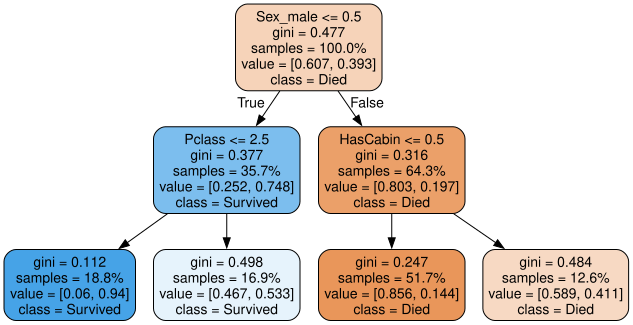

In [34]:
dot_data = tree.export_graphviz(dt, out_file=None, filled=True, 
                                rounded=True, feature_names=features_response[:-1], 
                                proportion=True, class_names=['Died', 'Survived']) 
graph = graphviz.Source(dot_data) 
graph 

Dựa trên hình ảnh bạn cung cấp, đây là một **Cây quyết định (Decision Tree)** được huấn luyện trên dữ liệu Titanic để dự đoán khả năng sống sót của hành khách.

Dưới đây là phân tích chi tiết từng tầng của cây:

### 1. Nút Gốc (Root Node) - Quyết định quan trọng nhất
*   **Điều kiện:** `Sex_male <= 0.5` (Nghĩa là: Hành khách có phải là Nữ không? Vì thường `Male=1`, `Female=0`).
    *   Nếu **Đúng (True)**: Đi sang nhánh trái (Là Nữ).
    *   Nếu **Sai (False)**: Đi sang nhánh phải (Là Nam).
*   **Thông tin tại nút:**
    *   `samples = 100.0%`: Chứa toàn bộ dữ liệu.
    *   `value = [0.607, 0.393]`: 60.7% chết (Died), 39.3% sống (Survived).
    *   `class = Died`: Dự đoán mặc định ban đầu là Chết (vì tỷ lệ chết cao hơn).
*   **Ý nghĩa:** Giới tính là yếu tố quan trọng nhất quyết định sự sống còn trên tàu Titanic.

---

### 2. Nhánh Trái (Phụ nữ - Female)
Đây là nhóm có khả năng sống sót cao hơn.

*   **Nút quyết định cấp 2:** `Pclass <= 2.5` (Hạng vé là 1 hoặc 2?).
    *   **True (Hạng 1 & 2):** Đi xuống nút lá màu xanh đậm bên trái.
        *   `gini = 0.112`: Độ tinh khiết rất cao (Rất chắc chắn).
        *   `value = [0.06, 0.94]`: **94% sống sót**.
        *   `class = Survived`: Dự đoán là **Sống**.
    *   **False (Hạng 3):** Đi xuống nút lá màu xanh nhạt.
        *   `gini = 0.498`: Độ tinh khiết thấp (khá lộn xộn, gần 50/50).
        *   `value = [0.467, 0.533]`: 53.3% sống, 46.7% chết.
        *   `class = Survived`: Dự đoán là **Sống** (nhưng rủi ro cao hơn nhiều so với hạng sang).

> **Kết luận nhánh trái:** Phụ nữ ở khoang hạng nhất và hạng hai gần như chắc chắn sống sót. Phụ nữ ở khoang hạng ba cũng có cơ hội sống nhưng thấp hơn nhiều.

---

### 3. Nhánh Phải (Đàn ông - Male)
Đây là nhóm có nguy cơ tử vong cao.

*   **Nút quyết định cấp 2:** `HasCabin <= 0.5` (Không có phòng riêng/Cabin?).
    *   **True (Không có Cabin):** Đi xuống nút lá màu cam đậm.
        *   `gini = 0.247`: Độ tinh khiết khá tốt.
        *   `value = [0.856, 0.144]`: **85.6% chết**.
        *   `class = Died`: Dự đoán là **Chết**.
    *   **False (Có Cabin):** Đi xuống nút lá màu cam nhạt.
        *   `gini = 0.484`: Độ tinh khiết thấp.
        *   `value = [0.589, 0.411]`: 58.9% chết, 41.1% sống.
        *   `class = Died`: Dự đoán vẫn là **Chết**, nhưng cơ hội sống cao hơn đáng kể so với người không có cabin.

> **Kết luận nhánh phải:** Đàn ông đa phần là thiệt mạng. Tuy nhiên, nếu đàn ông có Cabin riêng (thường là người giàu/hạng sang), họ có khoảng 41% cơ hội sống sót, trong khi đàn ông không có cabin chỉ có 14% cơ hội.

---

### TỔNG KẾT CHIẾN LƯỢC CỦA MÔ HÌNH
Mô hình này đưa ra quy tắc sinh tồn đơn giản như sau:

1.  **Ưu tiên 1:** Phụ nữ và Trẻ em (đại diện qua giới tính trong dữ liệu này) -> Khả năng sống cao.
2.  **Ưu tiên 2:** Đẳng cấp xã hội (thể hiện qua `Pclass` và `HasCabin`).
    *   Phụ nữ giàu (Hạng 1, 2) -> **Sống**.
    *   Đàn ông nghèo (Không Cabin) -> **Chết**.

**Màu sắc trong hình:**
*   **Màu Xanh (Blue):** Dự đoán là **Sống (Survived)**. Màu càng đậm nghĩa là xác suất sống càng cao.
*   **Màu Cam (Orange):** Dự đoán là **Chết (Died)**. Màu càng đậm nghĩa là xác suất chết càng cao.

## Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau 

Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham 
số tốt nhất 

In [35]:
from sklearn.model_selection import GridSearchCV 
params = {
    'max_depth': list(range(1, 21)),              # Độ sâu của cây
    'min_samples_split': [2, 5, 10],              # Số mẫu tối thiểu để chia nút
    'criterion': ['gini', 'entropy']  } # Tiêu chuẩn đánh giá


dt = tree.DecisionTreeClassifier(random_state=42) #tree modal 

cv = GridSearchCV(dt, param_grid=params, 
                  scoring='roc_auc', # Đánh giá bằng roc_auc
               n_jobs=None, # khong chạy song song
               refit=True, 
               cv=4, # Cross-validation 4 lần
               verbose=1, 
               error_score=np.nan, 
               return_train_score=True) # cv is the best model. 
cv.fit(X_train, y_train) 

print(f"Tham số tốt nhất: {cv.best_params_}")
print(f"Độ chính xác tốt nhất trên tập train (CV mean): {cv.best_score_:.4f}")

# Đánh giá mô hình tối ưu trên tập test
best_dt = cv.best_estimator_
y_pred_opt = best_dt.predict(X_validation)
print(f"Độ chính xác trên tập Validation (Mô hình tối ưu): {accuracy_score(y_validation, y_pred_opt):.4f}")

Fitting 4 folds for each of 120 candidates, totalling 480 fits
Tham số tốt nhất: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 10}
Độ chính xác tốt nhất trên tập train (CV mean): 0.8605
Độ chính xác trên tập Validation (Mô hình tối ưu): 0.8212


Vẽ biểu đồ đánh giá mô hình với các tham số chiều sâu của cây khác nhau 

Text(0, 0.5, 'ROC AUC')

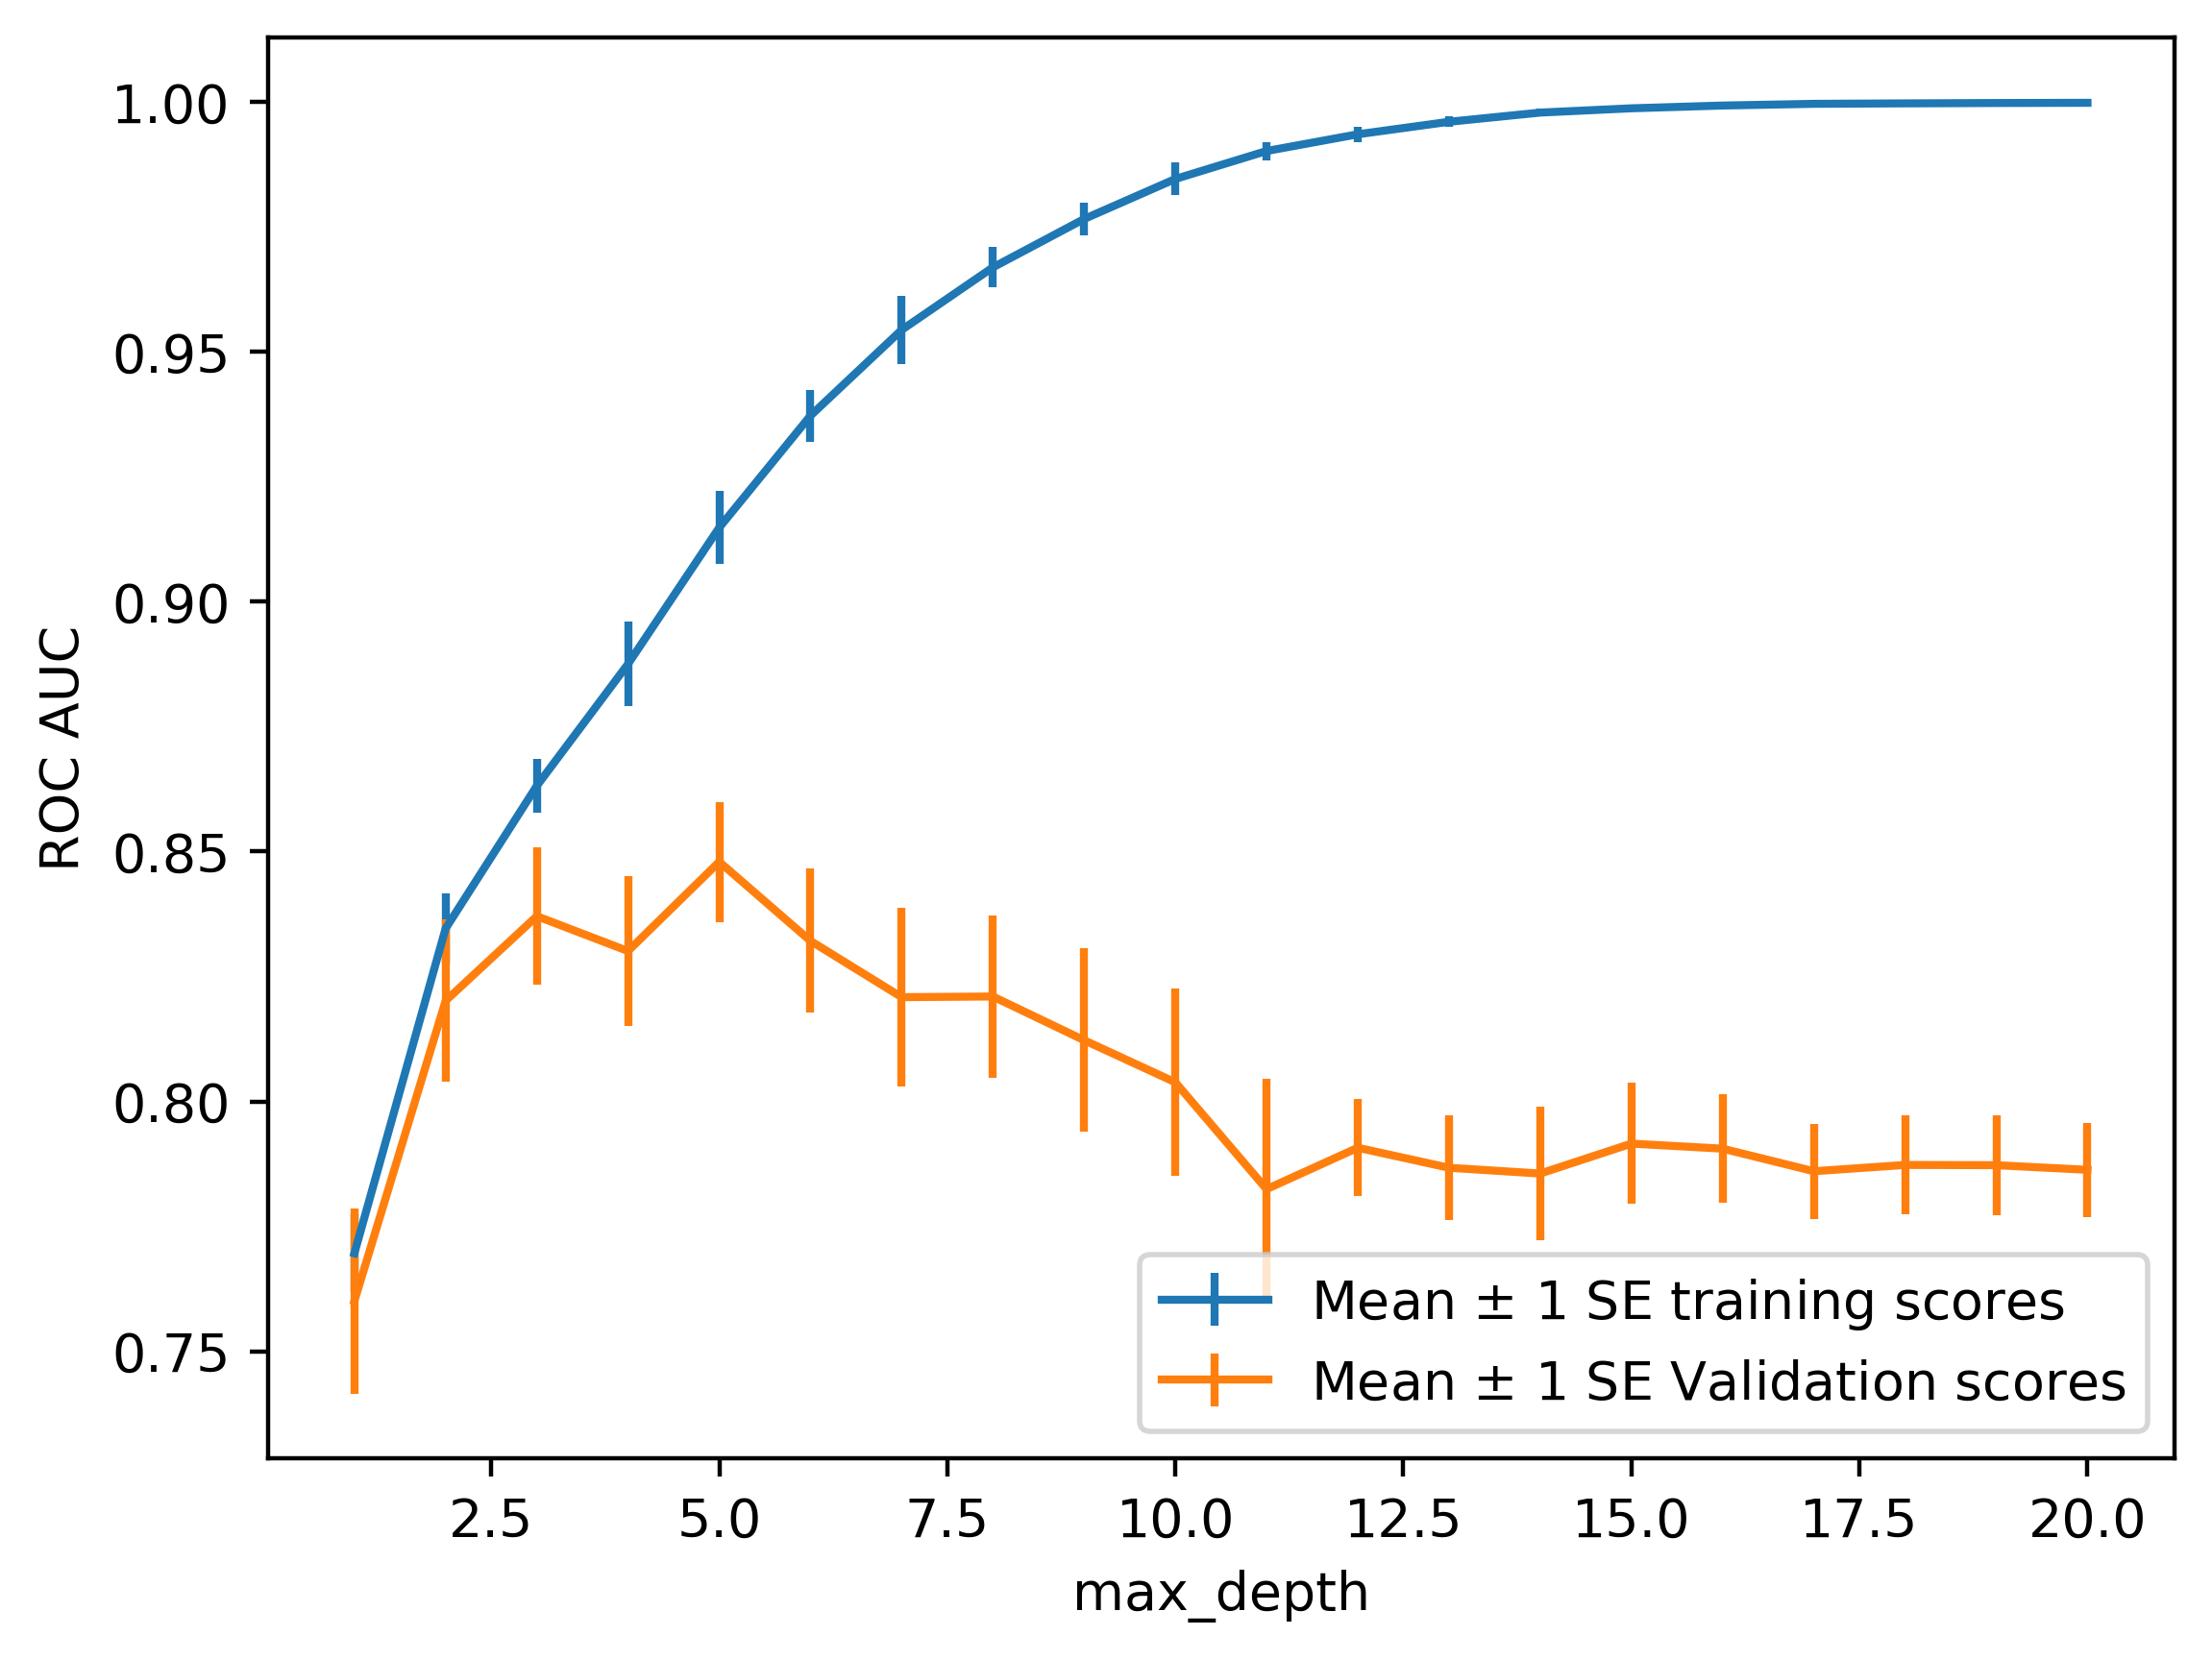

In [36]:
cv_results_df = pd.DataFrame(cv.cv_results_) #   Lấy kết quả từ grid search
cv_results_df.columns 

mask = (cv_results_df['param_criterion'] == 'gini') & (cv_results_df['param_min_samples_split'] == 2)
subset_results = cv_results_df[mask]

ax = plt.axes() 
ax.errorbar(subset_results['param_max_depth'], 
            subset_results['mean_train_score'], 
            yerr=subset_results['std_train_score']/np.sqrt(4), 
            label=r'Mean $\pm$ 1 SE training scores') 
ax.errorbar(subset_results['param_max_depth'], 
            subset_results['mean_test_score'], 
            yerr=subset_results['std_test_score']/np.sqrt(4), 
            label=r'Mean $\pm$ 1 SE Validation scores') 
ax.legend() 
plt.xlabel('max_depth') 
plt.ylabel('ROC AUC') 


### 1. Các thành phần trong biểu đồ
*   **Trục hoành (X-axis):** `max_depth` (từ 1 đến 20). Giá trị càng lớn nghĩa là cây càng sâu, càng phức tạp, càng có nhiều câu hỏi chi tiết "vụn vặt".
*   **Trục tung (Y-axis):** `ROC AUC`. Giá trị càng cao (gần 1.0) càng tốt.
*   **Đường màu xanh (Blue Line):** `Training scores`. Hiệu năng trên tập dữ liệu huấn luyện (dữ liệu mà mô hình đã "học thuộc").
*   **Đường màu cam (Orange Line):** `Validation scores`. Hiệu năng trên tập kiểm thử (dữ liệu mới mà mô hình chưa từng thấy).
*   **Các vạch dọc nhỏ (Error bars):** Độ lệch chuẩn (Standard Error), thể hiện sự biến động của kết quả qua các lần chạy Cross-Validation.

### 2. Phân tích xu hướng (Storytelling)

Biểu đồ kể câu chuyện qua 3 giai đoạn:

**Giai đoạn 1: Underfitting (Học chưa đủ) - `max_depth` từ 1 đến 3**
*   Cả đường xanh và đường cam đều đi lên mạnh mẽ.
*   Lúc này cây còn quá đơn giản (chỉ hỏi 1-2 câu hỏi), chưa đủ sức phân biệt tốt các mẫu dữ liệu.
*   Tăng độ sâu ở đây giúp cải thiện độ chính xác đáng kể cho cả hai tập.

**Giai đoạn 2: Điểm tối ưu (Sweet Spot) - `max_depth` khoảng 5 đến 6**
*   Đây là đỉnh cao của đường màu cam (Validation score đạt khoảng 0.85).
*   Tại đây, mô hình đủ phức tạp để hiểu quy luật chung của dữ liệu nhưng chưa quá phức tạp để học thuộc lòng các nhiễu.
*   **Kết luận:** Tham số `max_depth` tốt nhất nên chọn là **5 hoặc 6**.

**Giai đoạn 3: Overfitting (Học vẹt) - `max_depth` > 6**
*   **Đường màu xanh (Train):** Vẫn tiếp tục tăng vùn vụt, tiệm cận mức hoàn hảo 1.0. Cây càng sâu, nó càng "nhớ" chính xác từng mẫu dữ liệu huấn luyện.
*   **Đường màu cam (Validation):** Bắt đầu **đi xuống** và sau đó đi ngang ở mức thấp hơn đỉnh cũ.
*   **Khoảng cách (Gap):** Khoảng cách giữa hai đường ngày càng rộng ra. Điều này chứng tỏ mô hình chỉ giỏi "chém gió" trên bài đã học, nhưng khi gặp bài thi thật (Validation) thì làm kém đi vì nó đã học cả những tạp nhiễu vô nghĩa.

### 3. Kết luận hành động
Nếu bạn đang xây dựng mô hình này:

1.  **Chọn `max_depth = 5` (hoặc 6):** Đây là điểm cân bằng tốt nhất giữa độ chính xác và khả năng tổng quát hóa.
2.  **Không chọn `max_depth = 20`:** Mặc dù Train score gần như tuyệt đối, nhưng thực tế nó hoạt động kém hơn nhiều so với cây có độ sâu 5. Nó đang lãng phí tài nguyên tính toán và đưa ra dự đoán kém tin cậy hơn.

## Xây dựng rừng cây (random forest) 

Tạo rừng cây với lớp RandomForestClassifier trong Scikit-Learn

In [37]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Khởi tạo mô hình cơ sở
rf_base = RandomForestClassifier(random_state=42)

# 2. Thiết lập lưới tham số CHUYÊN BIỆT cho Random Forest
# Lưu ý: Random Forest thường cần n_estimators lớn và max_depth sâu hơn
rf_params = {
    'n_estimators': [50, 100, 200],       # Số lượng cây
    'max_depth': [None, 10, 15, 20],      # Độ sâu (None là không giới hạn)
    'min_samples_split': [2, 5, 10],      # Số mẫu tối thiểu để chia nút
    'max_features': ['sqrt', 'log2']      # Số đặc trưng xem xét tại mỗi lần chia
}

print("Đang tìm tham số tối ưu cho Random Forest...")
cv_rf = GridSearchCV(rf_base, param_grid=rf_params, scoring='roc_auc',
                     n_jobs=-1, # Chạy song song để nhanh hơn
                     cv=4, verbose=1)

cv_rf.fit(X_train, y_train)

# 3. In kết quả tốt nhất
print(f"Tham số tốt nhất cho RF: {cv_rf.best_params_}")
print(f"ROC-AUC tốt nhất trên tập Train: {cv_rf.best_score_:.4f}")

# 4. Đánh giá trên tập Validation
best_rf = cv_rf.best_estimator_
y_pred_rf = best_rf.predict(X_validation)

print("\n--- KẾT QUẢ TRÊN TẬP VALIDATION ---")
print(f"Độ chính xác (Accuracy): {accuracy_score(y_validation, y_pred_rf):.4f}")

Đang tìm tham số tối ưu cho Random Forest...
Fitting 4 folds for each of 72 candidates, totalling 288 fits
Tham số tốt nhất cho RF: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
ROC-AUC tốt nhất trên tập Train: 0.8754

--- KẾT QUẢ TRÊN TẬP VALIDATION ---
Độ chính xác (Accuracy): 0.8380


rf = RandomForestClassifier(..., max_depth=cv.best_params_['max_depth'], ...)
Vấn đề: Đang ép Random Forest sử dụng max_depth tối ưu của Cây quyết định đơn lẻ.

Tại sao không nên? Một cây quyết định đơn lẻ rất dễ bị overfitting (học vẹt), nên nó cần bị giới hạn độ sâu (ví dụ depth=7). Ngược lại, Random Forest là tập hợp của nhiều cây, cơ chế của nó tự giảm thiểu variance (độ phương sai). Do đó, các cây con trong Random Forest thường cần sâu hơn (thậm chí không giới hạn độ sâu) để học được các mẫu phức tạp. Việc giới hạn độ sâu theo cây đơn lẻ sẽ làm giảm sức mạnh của Rừng.

 Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó

In [38]:
#a parameter grid for this exercise in order to search the numbers of trees, ranging from 10 to 100 by 10s 
rf_params_ex = {'n_estimators':list(range(10,110,10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex, scoring='roc_auc',
                        n_jobs=None, refit=True, cv=4, verbose=1,
                        error_score=0.0,
                        return_train_score=True)
cv_rf_ex.fit(X_train, y_train)

y_pred_rf = cv_rf_ex.predict(X_validation)

print("Báo cáo phân loại Random Forest:")
print(classification_report(y_validation, y_pred_rf))
print(f"Độ chính xác Random Forest: {accuracy_score(y_validation, y_pred_rf):.4f}")


Fitting 4 folds for each of 10 candidates, totalling 40 fits
Báo cáo phân loại Random Forest:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       117
           1       0.76      0.77      0.77        62

    accuracy                           0.84       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.84      0.84      0.84       179

Độ chính xác Random Forest: 0.8380


Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau

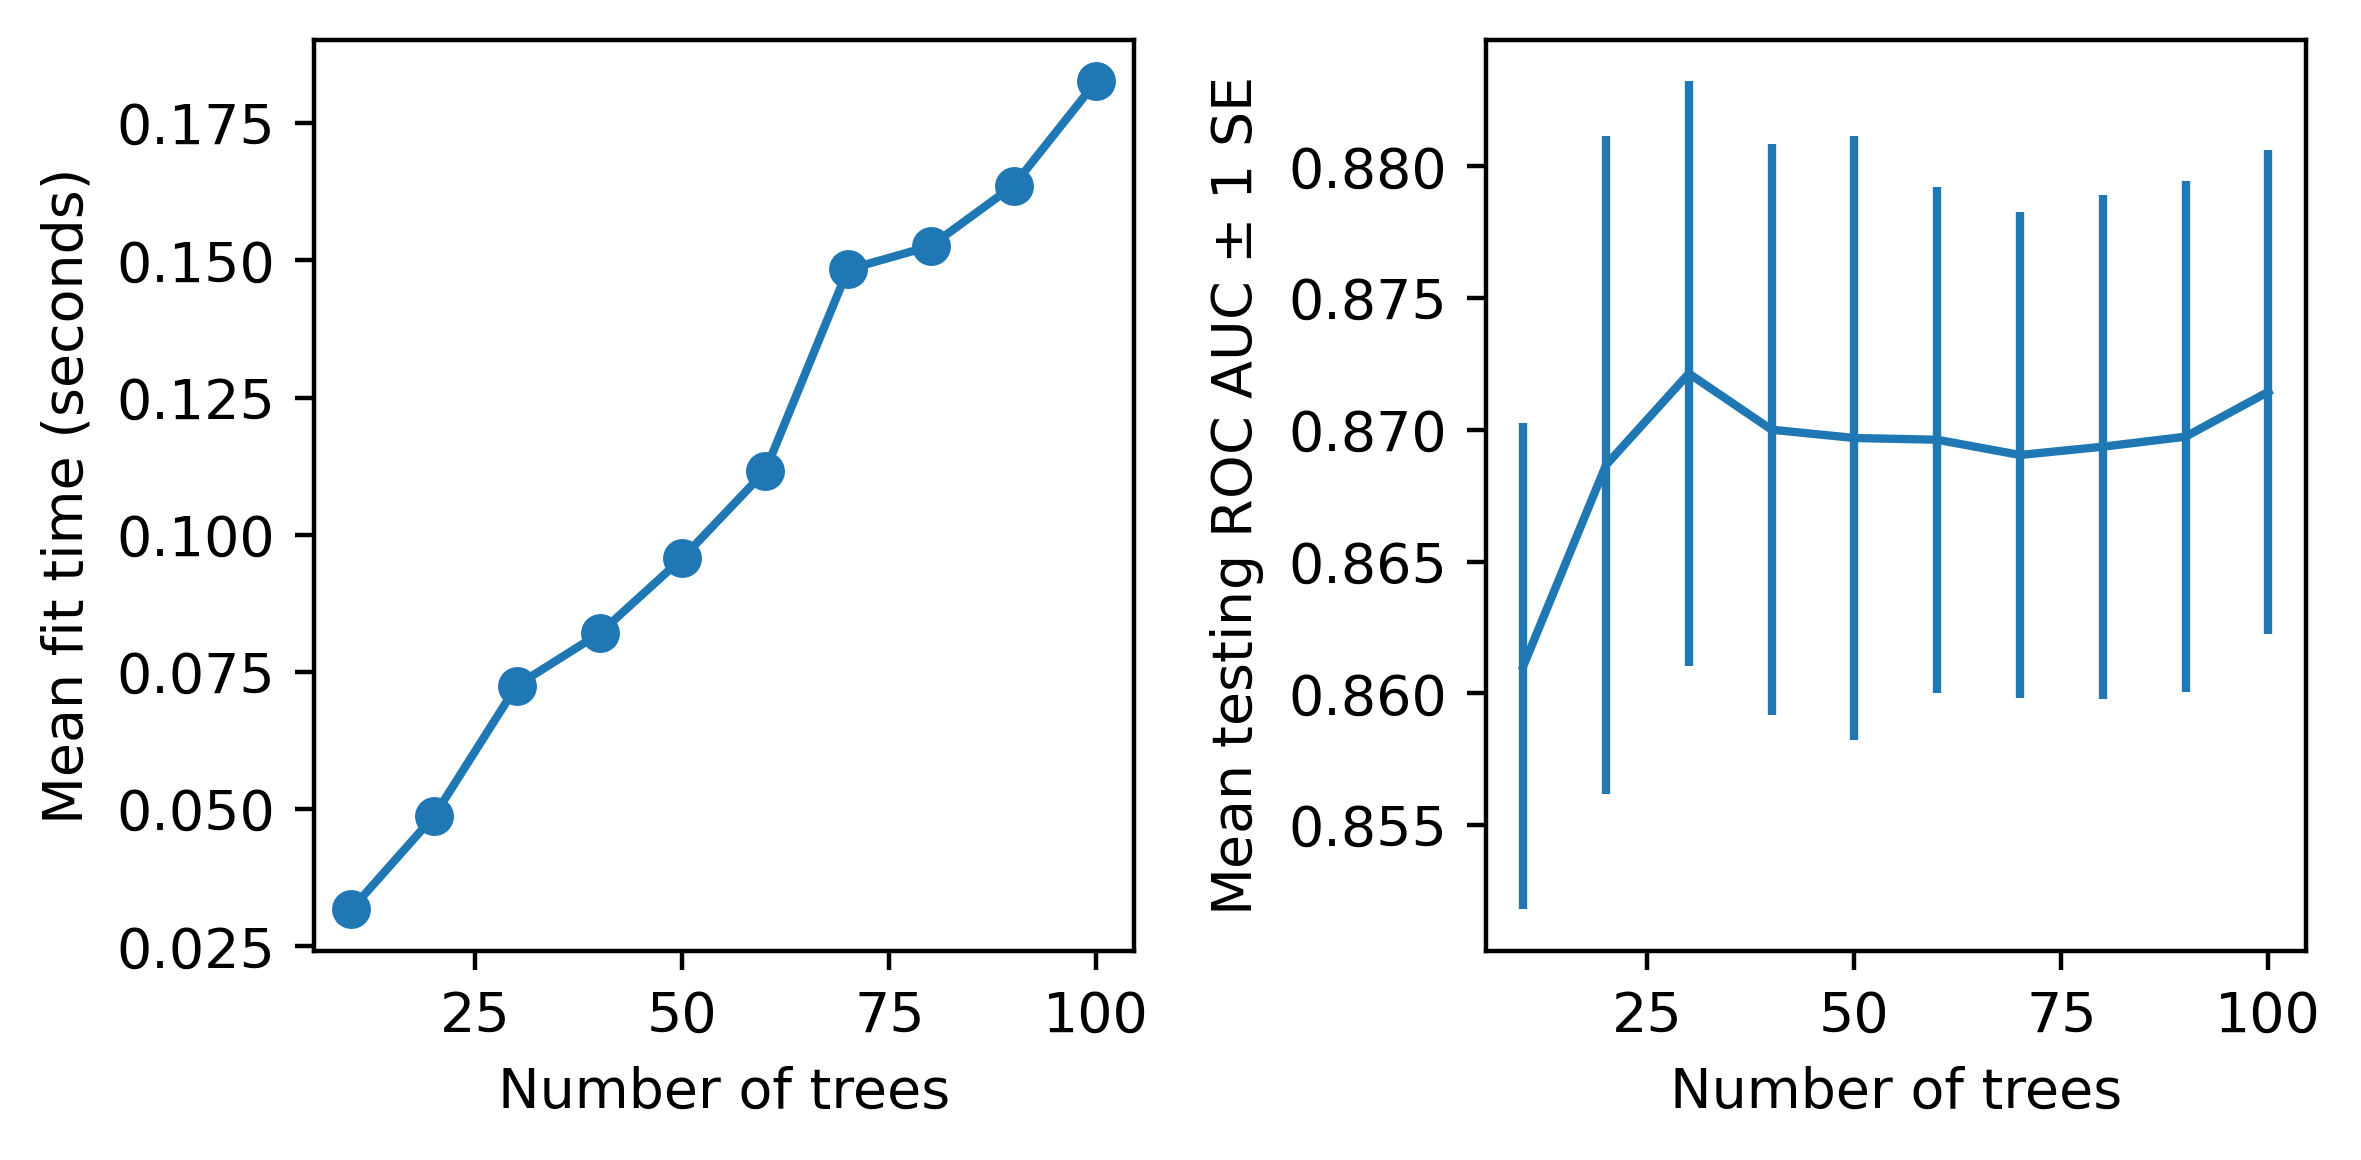

In [39]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_) 
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3)) 

axs[0].plot(cv_rf_ex_results_df['param_n_estimators'], 
cv_rf_ex_results_df['mean_fit_time'], '-o') 

axs[0].set_xlabel('Number of trees') 
axs[0].set_ylabel('Mean fit time (seconds)') 

axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'], 
cv_rf_ex_results_df['mean_test_score'], 
yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4)) 

axs[1].set_xlabel('Number of trees') 
axs[1].set_ylabel(r'Mean testing ROC AUC $\pm$ 1 SE ') 
plt.tight_layout() 


### 1. Biểu đồ bên trái: Thời gian huấn luyện (Mean fit time)
*   **Trục hoành (X):** Số lượng cây (`n_estimators`) từ khoảng 10 đến 100.
*   **Trục tung (Y):** Thời gian huấn luyện trung bình tính bằng giây.
*   **Xu hướng:**
    *   Đường biểu diễn là một đường thẳng đi lên (tuyến tính).
    *   **Ý nghĩa:** Mối quan hệ giữa số lượng cây và thời gian chạy là **tỷ lệ thuận**. Nếu bạn tăng gấp đôi số cây (ví dụ từ 50 lên 100), thời gian huấn luyện cũng tăng gấp đôi (từ ~0.1s lên ~0.18s).
    *   **Bài học:** Càng nhiều cây thì mô hình chạy càng lâu. Tuy nhiên, với dữ liệu nhỏ này, thời gian chỉ tính bằng mili-giây nên không đáng kể. Với dữ liệu lớn (Big Data), đây là yếu tố phải cân nhắc kỹ.

### 2. Biểu đồ bên phải: Hiệu năng mô hình (Mean testing ROC AUC)
*   **Trục hoành (X):** Số lượng cây (`n_estimators`).
*   **Trục tung (Y):** Điểm ROC AUC trung bình trên tập kiểm thử (Testing score).
*   **Các vạch dọc (Error Bars):** Thể hiện độ lệch chuẩn (sự biến động của kết quả qua các lần kiểm thử chéo - Cross Validation).
*   **Xu hướng:**
    *   **Giai đoạn đầu (< 30 cây):** Hiệu năng tăng rất nhanh. Từ khoảng 0.860 lên đỉnh điểm 0.872. Điều này cho thấy việc thêm cây giúp mô hình ổn định và học tốt hơn.
    *   **Giai đoạn bão hòa (> 30 cây):** Đường biểu diễn đi ngang, thậm chí hơi giảm nhẹ rồi dao động quanh mức 0.870. Các vạch sai số (error bars) cũng khá dài, cho thấy sự ổn định không thay đổi nhiều.
    *   **Ý nghĩa:** Sau một ngưỡng nhất định (ở đây là khoảng 30 cây), việc thêm nhiều cây nữa **không làm tăng độ chính xác** đáng kể. Nó chỉ làm tốn thêm tài nguyên máy tính (như biểu đồ bên trái đã chứng minh).

### TỔNG KẾT & KIẾN NGHỊ
Kết hợp cả hai biểu đồ, ta rút ra kết luận quan trọng để chọn tham số (`tuning`):

1.  **Điểm tối ưu (Sweet Spot):** Khoảng **30 đến 40 cây**.
    *   Tại đây, hiệu năng (ROC AUC) đạt mức cao nhất (~0.872).
    *   Thời gian huấn luyện vẫn thấp.
2.  **Tại sao không chọn 100 cây?**
    *   Mặc dù 100 cây là mức thường dùng mặc định, nhưng trong trường hợp cụ thể này, nó không mang lại lợi ích gì thêm về độ chính xác so với 40 cây, mà lại tốn gấp đôi thời gian chạy.
3.  **Quy luật lợi ích cận biên giảm dần:** Trong Random Forest, ban đầu thêm cây giúp giảm sai số (variance), nhưng đến lúc "đủ" rồi thì thêm nữa cũng vô ích.

**Lời khuyên:** Nếu phải chọn tham số cho mô hình này, hãy chọn `n_estimators = 30` hoặc `40` để vừa nhanh vừa chính xác.

Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham 
số tốt nhất 

<Axes: >

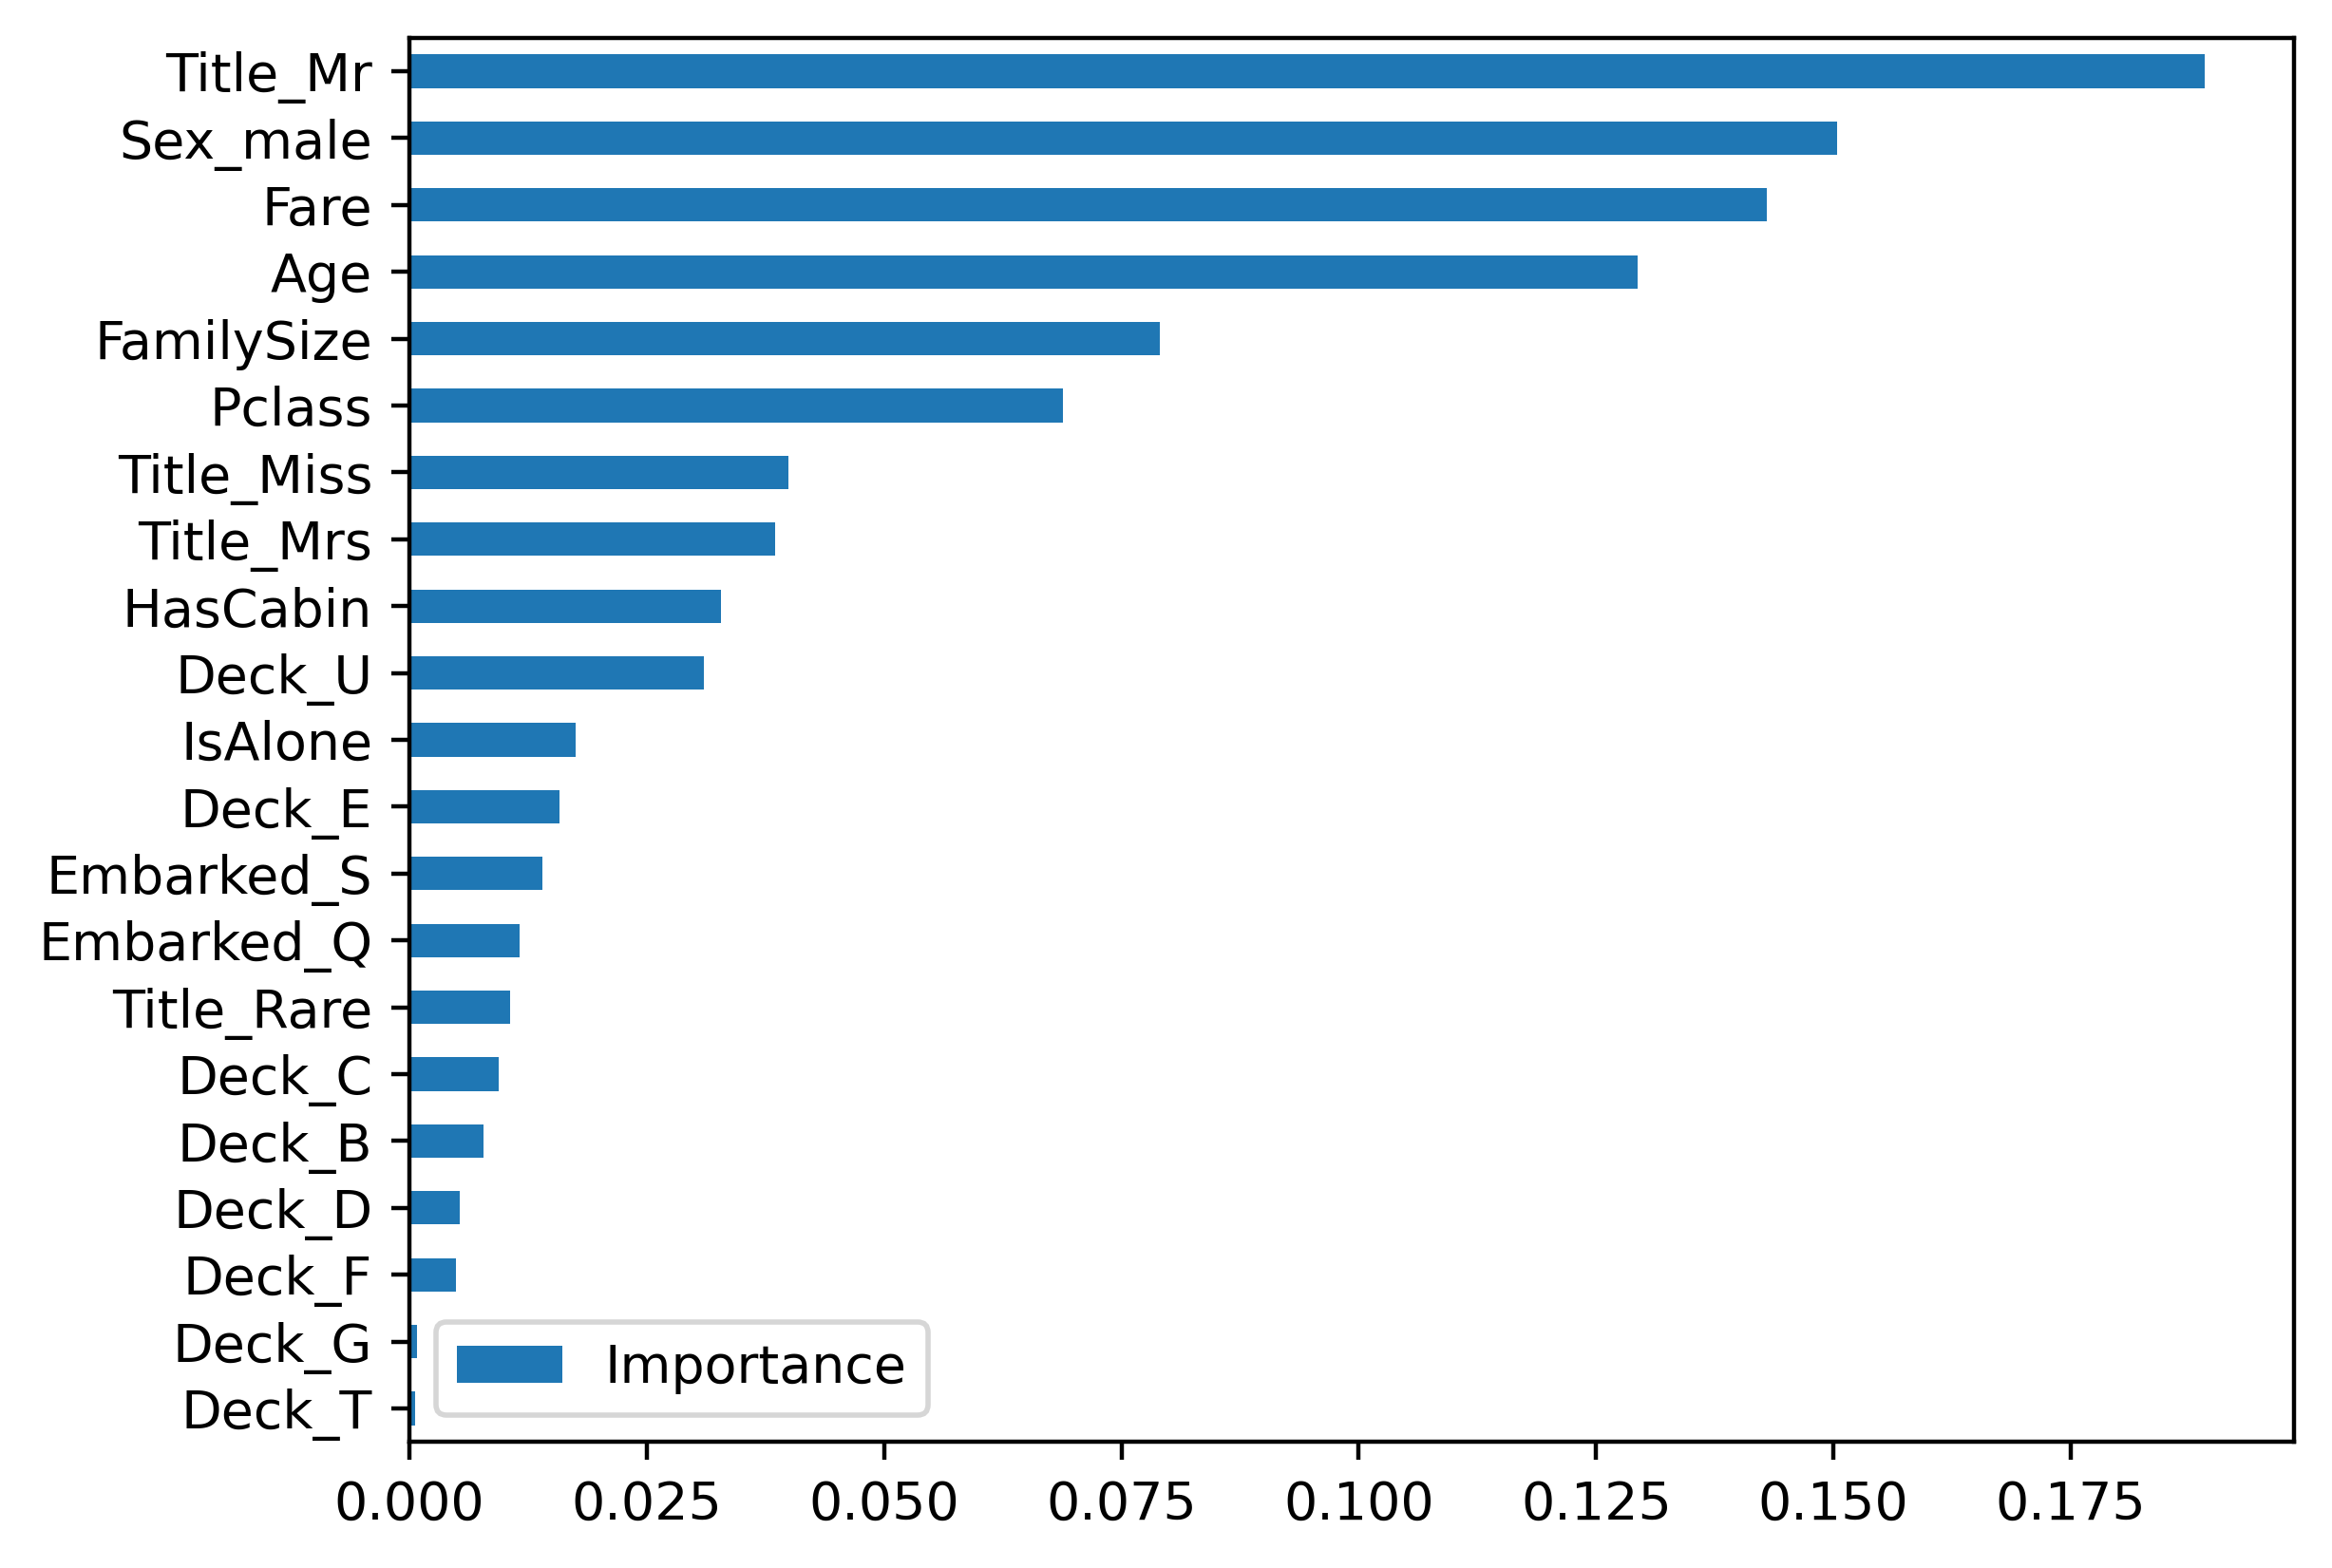

In [40]:
# {'n_estimators': 50} 
cv_rf_ex.best_params_ 
# the feature names and importances 
feat_imp_df = pd.DataFrame({ 
'Importance':cv_rf_ex.best_estimator_.feature_importances_}, 
index=features_response[:-1]) 
feat_imp_df.sort_values('Importance', ascending=True).plot.barh()

<Figure size 3200x2400 with 0 Axes>

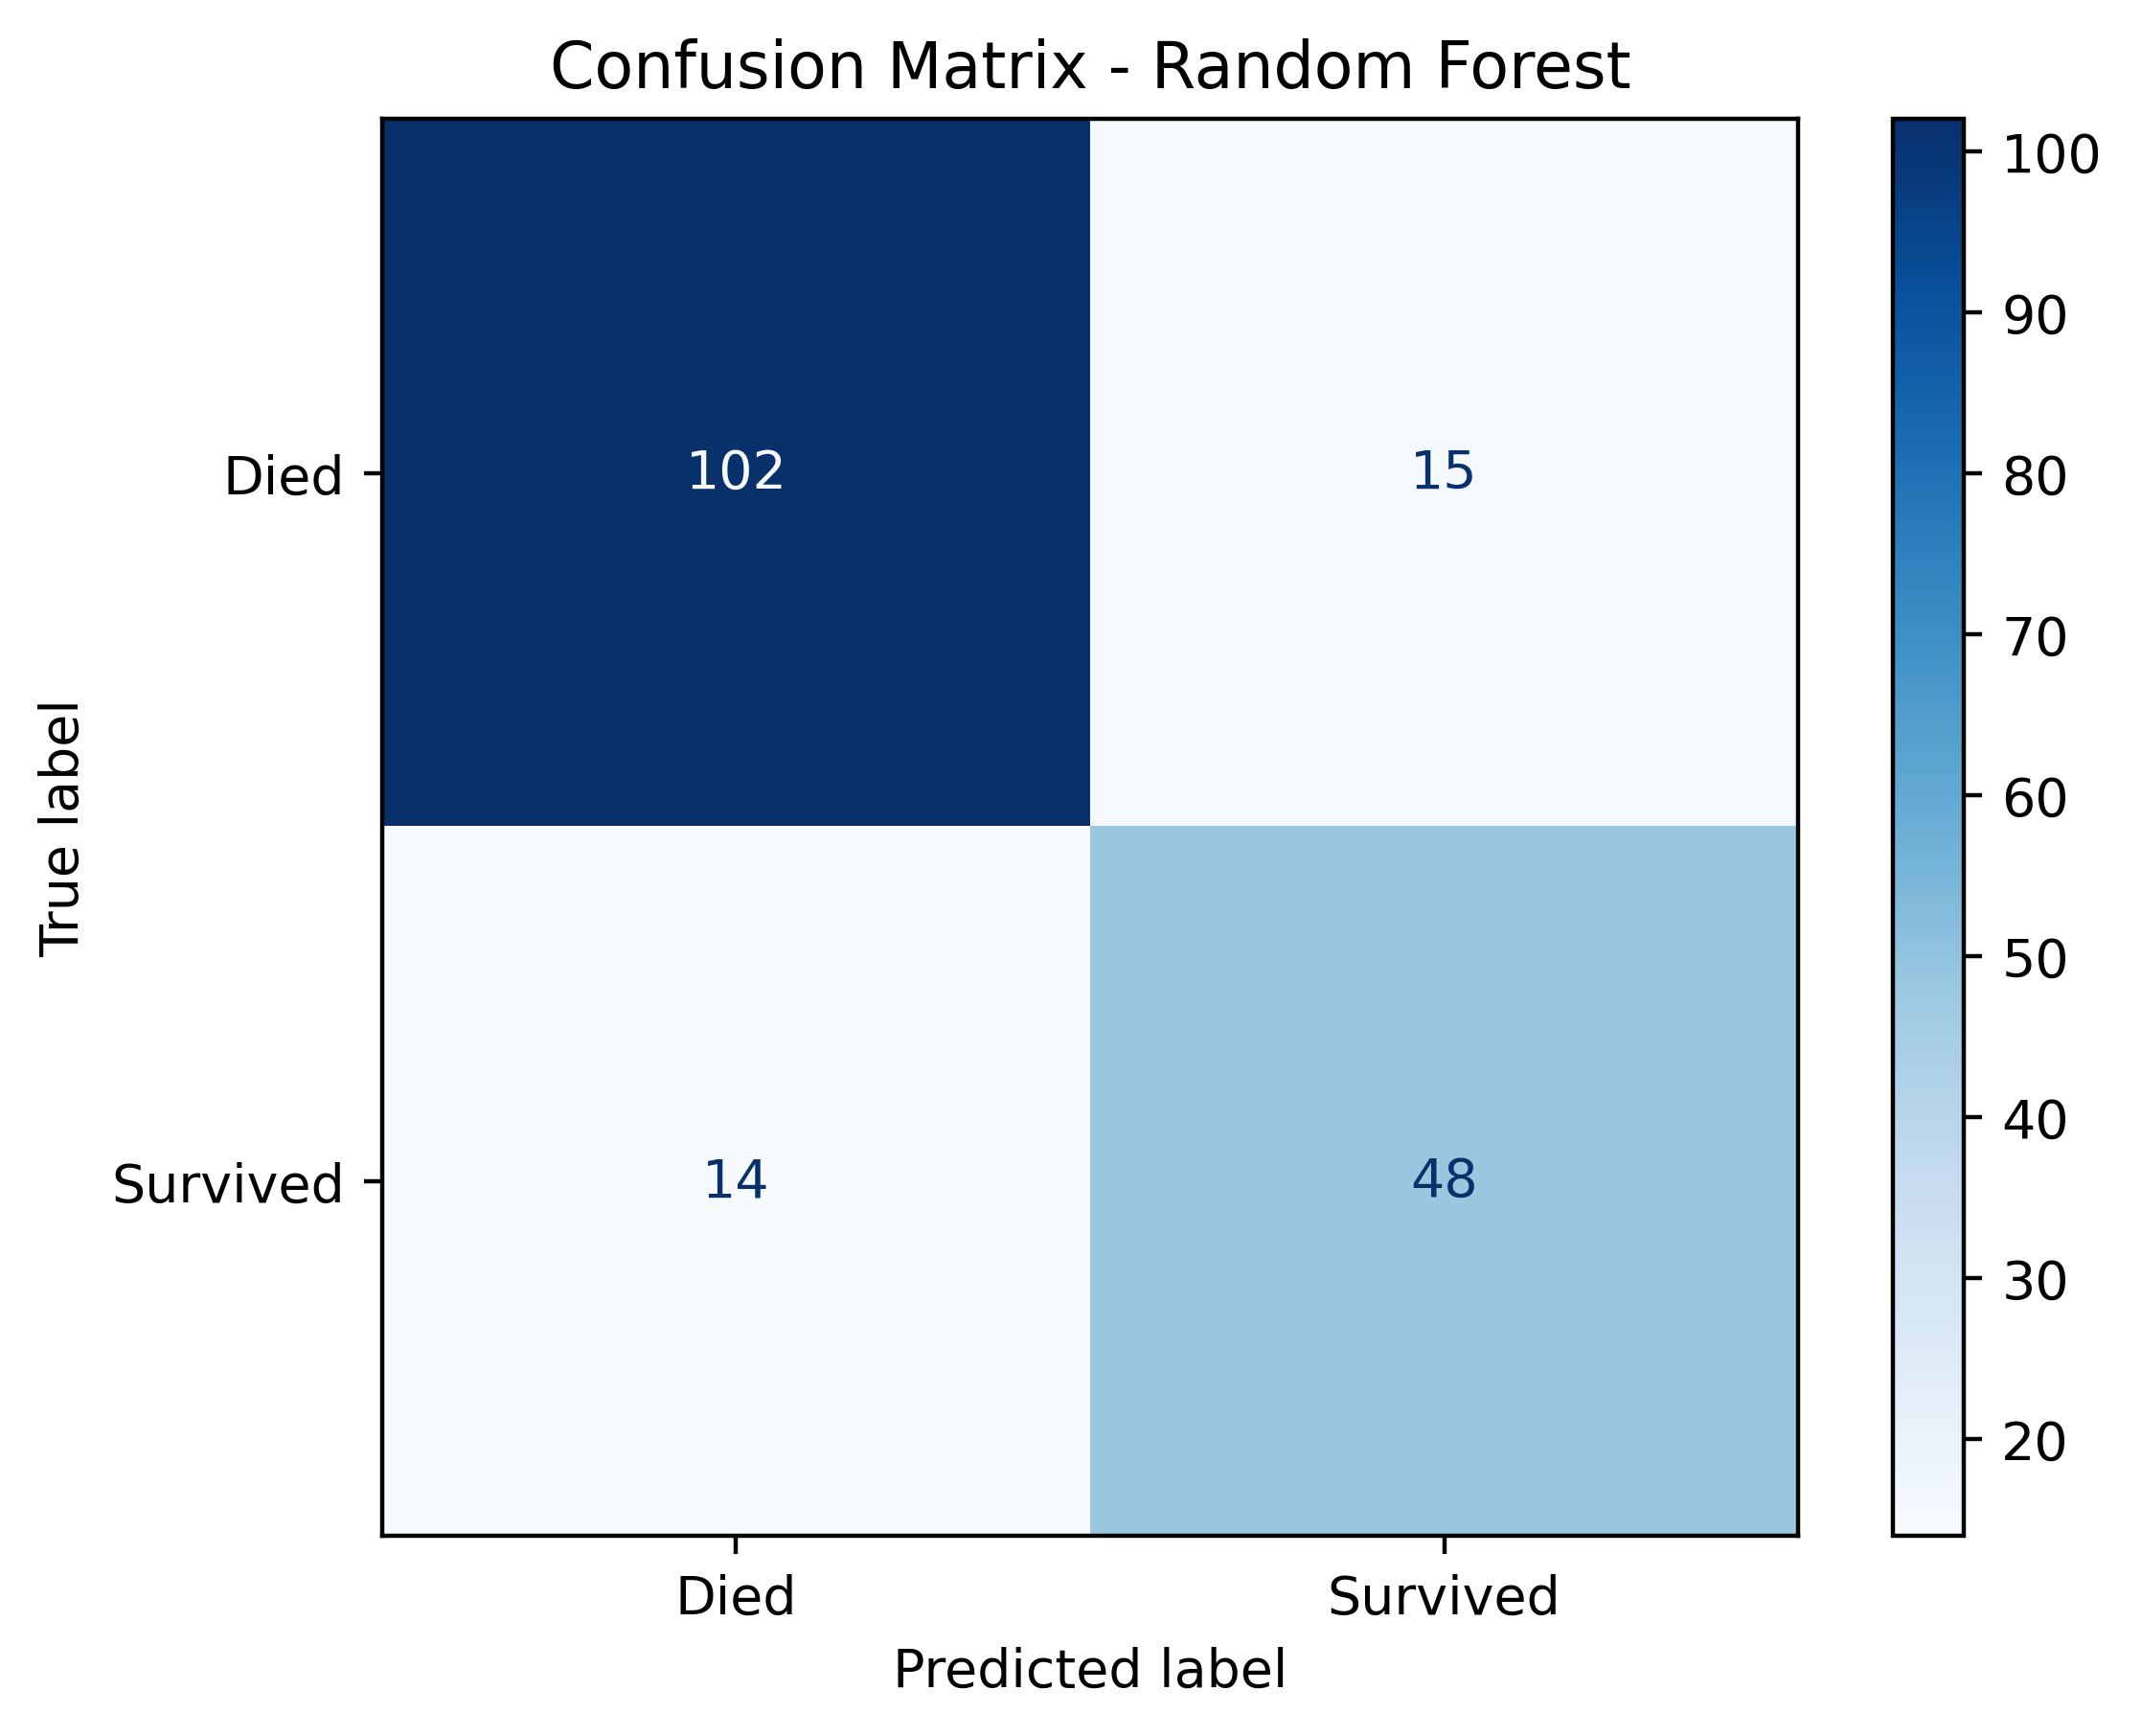

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Tính toán confusion matrix
cm = confusion_matrix(y_validation, y_pred_rf)

# Vẽ
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()
plt.close()

Chỉ nhìn Accuracy là chưa đủ. Vẽ Confusion Matrix để xem mô hình đang nhầm lẫn ở đâu (ví dụ: dự đoán người chết thành sống hay ngược lại).

C:\Users\DELL\AppData\Local\Temp\ipykernel_8664\2522003204.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


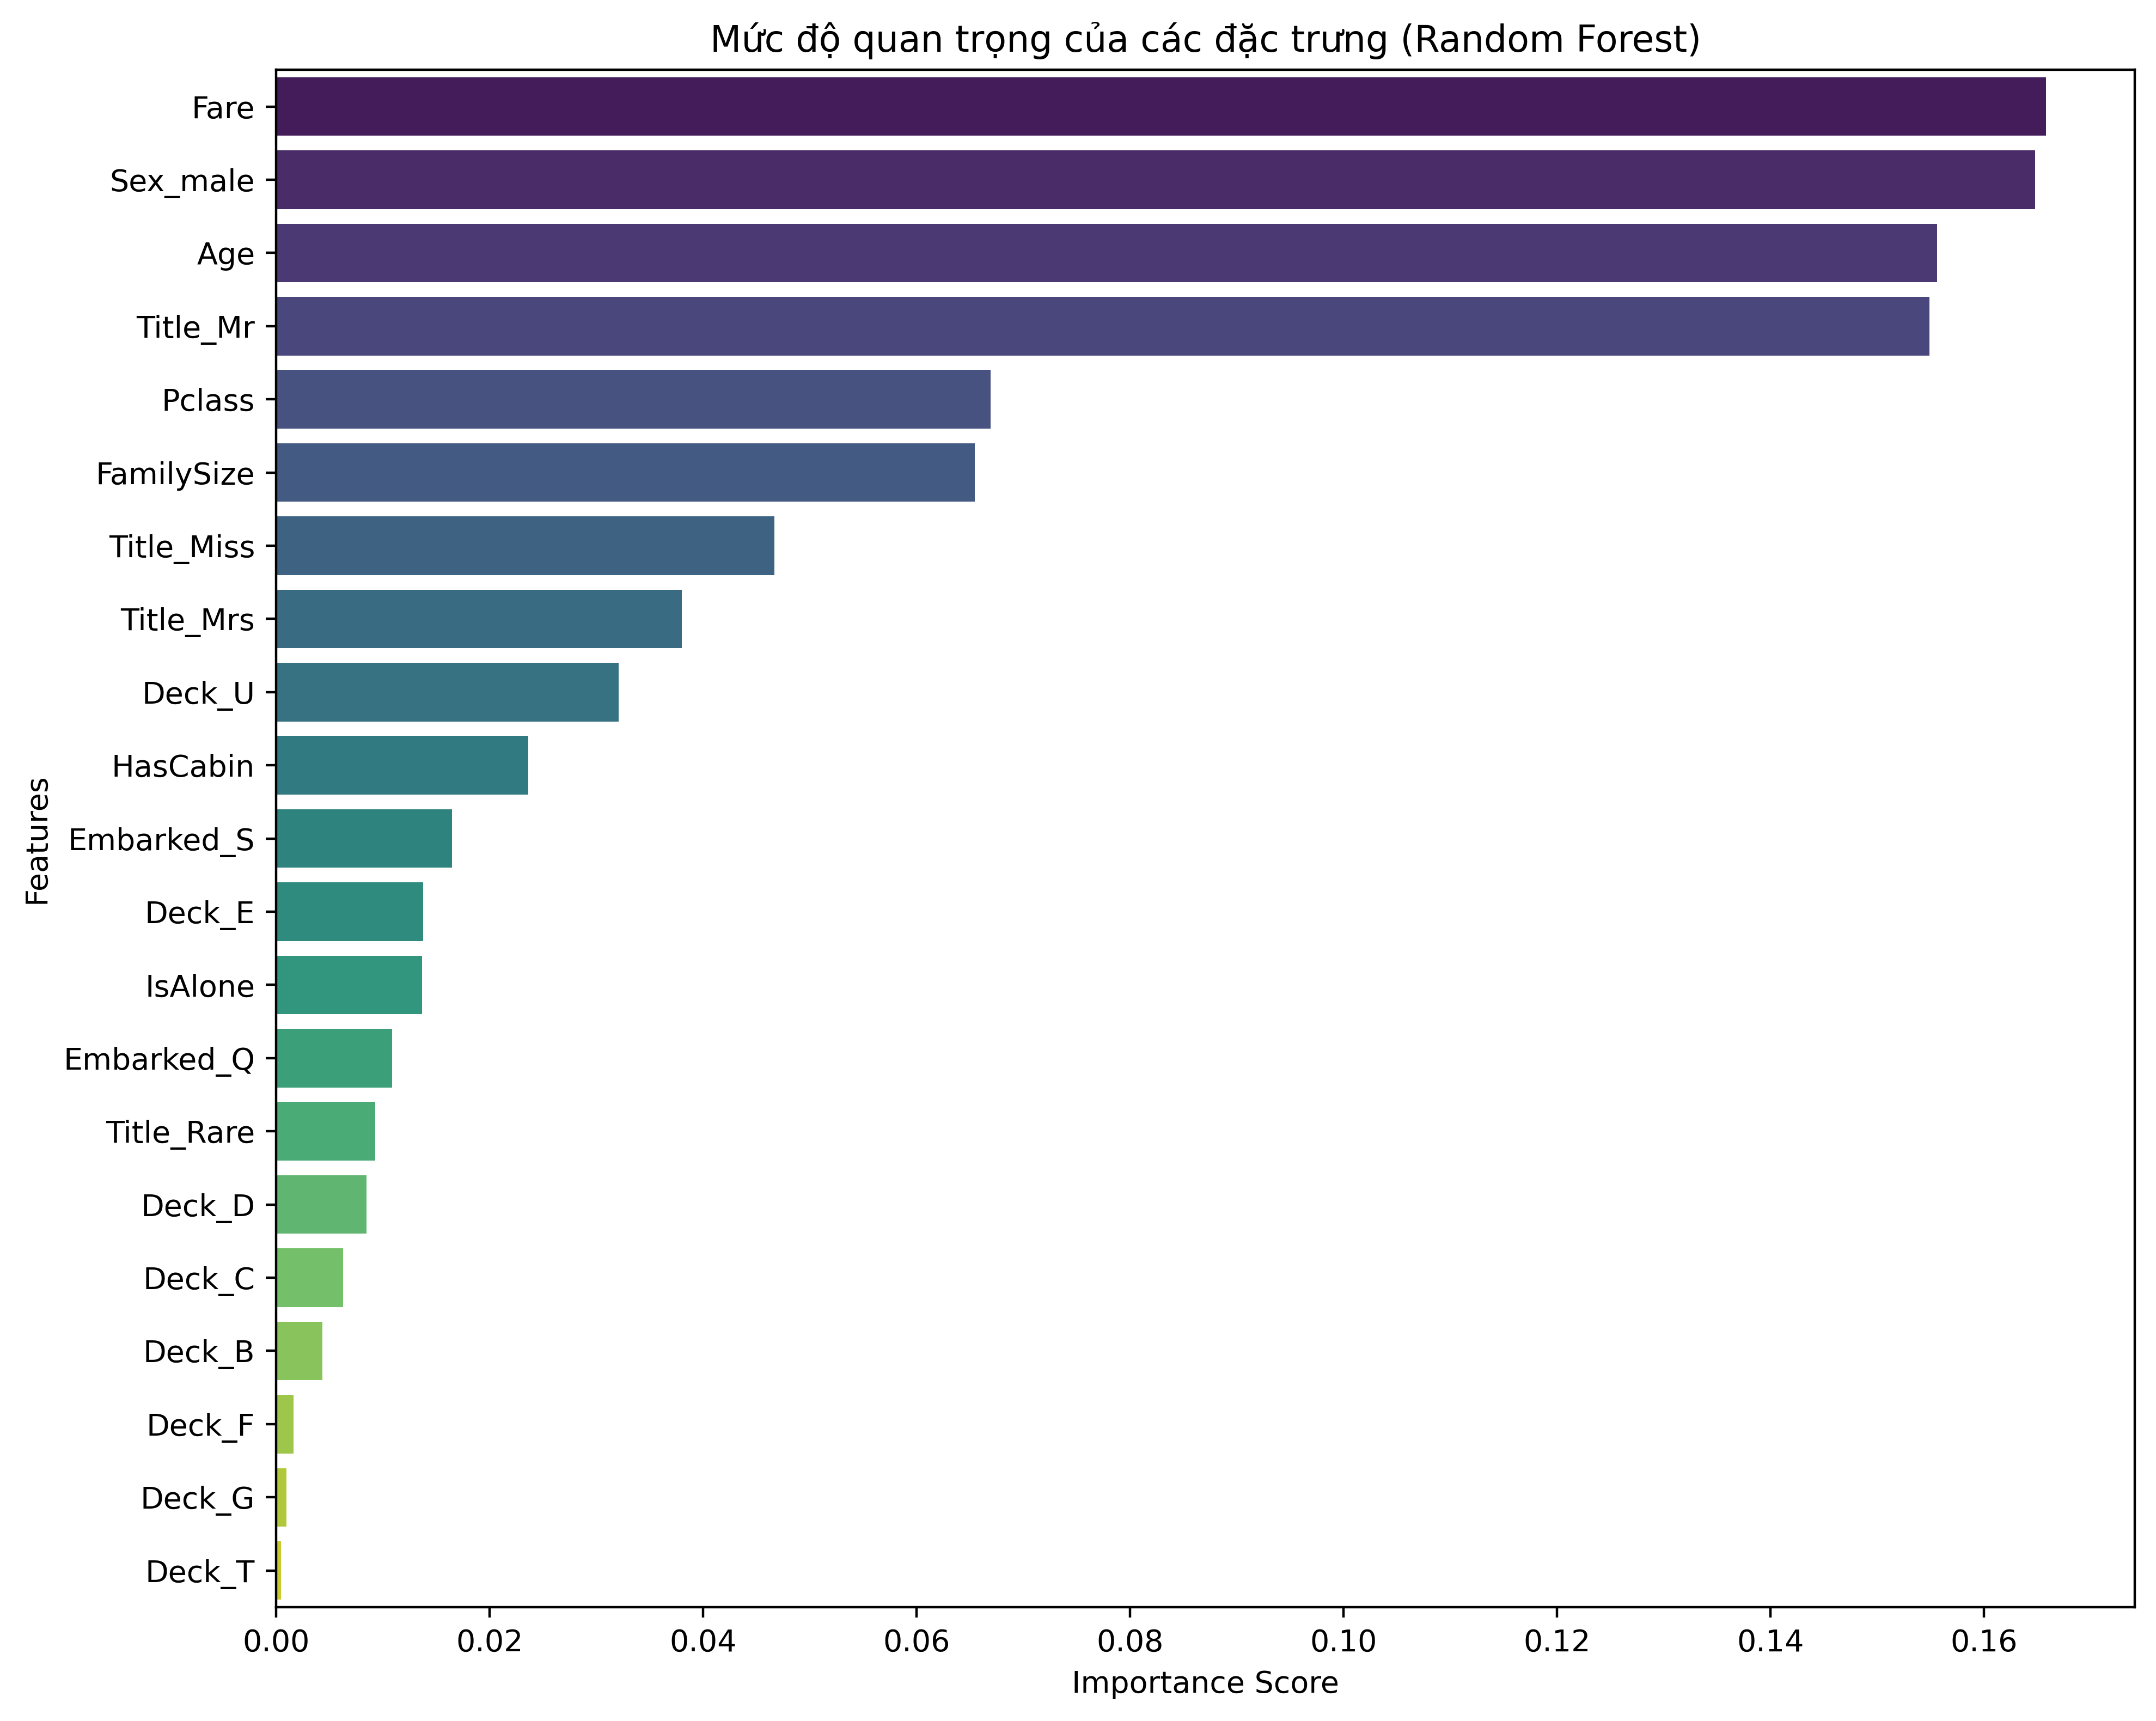

In [ ]:

import pandas as pd
import seaborn as sns

# Lấy feature importance từ mô hình tốt nhất
importances = best_rf.feature_importances_
feature_names = features_response[:-1]

# Tạo DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sắp xếp giảm dần
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ đẹp hơn với Seaborn
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Mức độ quan trọng của các đặc trưng (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
plt.close()